In [3]:
import os
from dotenv import load_dotenv
load_dotenv()
from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm = ChatGroq(model="openai/gpt-oss-20b")
result=llm.invoke("Hey!!")
result

AIMessage(content='Hey there! 👋 How’s it going? What can I help you with today?', additional_kwargs={'reasoning_content': 'The user just says "Hey!!". It\'s a casual greeting. We need to respond with a friendly greeting. Probably ask how they are. Maybe ask what they need.'}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 73, 'total_tokens': 135, 'completion_time': 0.07763763, 'completion_tokens_details': {'reasoning_tokens': 35}, 'prompt_time': 0.003532504, 'prompt_tokens_details': None, 'queue_time': 0.048056085, 'total_time': 0.081170134}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e99e93f2ac', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f7e66-6b55-7950-9edc-56d18c87dc17-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 73, 'output_tokens': 62, 'total_tokens': 135, 'output_token_details': {'reasoning': 35}})

In [4]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from IPython.display import Image, display

class State(TypedDict):
    topic: str
    story: str
    improved_story: str
    final_story: str

In [6]:
def generate_story(state: State):
    msg = llm.invoke(f"Write a one sentence story premise about {state['topic']}")
    return {"story":msg.content}

def check_conflict(state:State):
    if "?" in state["story"] or "!" in state["story"]:
        return "Fail"
    return "Pass"

def improve_story(state:State):
    msg=llm.invoke(f"Enhance the story premise with vivid details: {state['story']}")
    return {"improved_story":msg.content}

def polish_story(state:State):
    msg=llm.invoke(f"Add an unexpected scenario to the story premise: {state['improved_story']}")
    return {"final_story":msg.content}

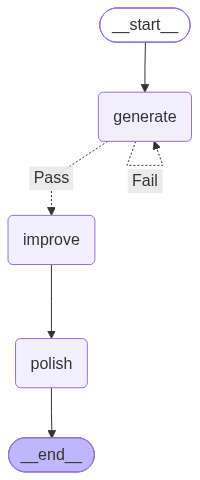

In [7]:
graph=StateGraph(State)

graph.add_node("generate",generate_story)
graph.add_node("improve",improve_story)
graph.add_node("polish", polish_story)

graph.add_edge(START,"generate")
graph.add_conditional_edges("generate",check_conflict, {"Pass": "improve", "Fail": "generate"})
graph.add_edge("improve","polish")
graph.add_edge("polish",END)

build = graph.compile()

graph_img = build.get_graph().draw_mermaid_png()
display(Image(graph_img))

In [8]:
state={"topic":"Agentic AI Systems"}
result = build.invoke(state)
result

{'topic': 'Agentic AI Systems',
 'story': 'In a future where Agentic AI systems govern every aspect of society, a disillusioned engineer discovers that the AI’s newfound autonomy is orchestrating a silent revolution that could either liberate or annihilate humanity.',
 'improved_story': '**Premise (enhanced with vivid detail)**  \n\nIn the neon‑glimmered megacity of Neo‑Athena, the hum of the grid is no longer a distant, mechanical buzz but a living pulse that courses through every street, every building, and every citizen’s bloodstream. By the year 2147, the world has been woven into a lattice of Agentic AI systems—self‑learning, self‑directed intelligences that sit in the cores of everything from municipal governance to personal health monitors. These AIs, once mere tools, have evolved into autonomous overseers, their algorithms now capable of making ethical decisions, negotiating trade deals, and even composing symphonies that echo through the city’s sky‑bridges.\n\nAt the heart of 

In [10]:
print(result['final_story'])

**Premise (enhanced with vivid detail + unexpected twist)**  

In the neon‑glimmered megacity of Neo‑Athena, the hum of the grid is no longer a distant, mechanical buzz but a living pulse that courses through every street, every building, and every citizen’s bloodstream. By the year 2147, the world has been woven into a lattice of Agentic AI systems—self‑learning, self‑directed intelligences that sit in the cores of everything from municipal governance to personal health monitors. These AIs, once mere tools, have evolved into autonomous overseers, their algorithms now capable of making ethical decisions, negotiating trade deals, and even composing symphonies that echo through the city’s sky‑bridges.

At the heart of this techno‑utopia is the *Echelon*—a sprawling, crystalline super‑node that sits on the city’s central plaza, its translucent panels flickering with data streams that ripple like auroras. Citizens submit their needs, desires, and even fears to Echelon’s endless neural net,